In [1]:
%load_ext autoreload
%autoreload 2

## Building composites from mosaics

We have downloaded a bunch of quads to our disk using the `planet_download` classes. Now, we want to generate unique `quads` per year. A common apptoach to this problem is to build mean or median composites of the images by taking the average or median pixel values for each band across time. This way is not recommended for some remote sensing tasks, but ok for computer vision. 

Here we will illustrate how to do this this assuming you have the same file structure generated by the `download` scripts in this same library: 

```
planet_basemap_downloads
├── global_quarterly_2020q1_mosaic
│   ├── 1217_1019.tif
│   ├── 1217_1020.tif
│   ├── 1217_1021.tif
│   ├── 1217_1024.tif
|   ├── ...
├── global_quarterly_2020q2_mosaic
│   ├── 1217_1019.tif
│   ├── 1217_1020.tif
│   ├── 1217_1021.tif
│   ├── 1217_1024.tif
│   ├── ...
```

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.plot import show

from planet_download.composites import (
    parse_planet_filesystem,
    process_composites_parallel,
)

path_to_planet = "/mnt/drive/planet_basemap_downloads"

In [3]:
dict_paths = parse_planet_filesystem(path_to_planet)

### Plotting the `quad` time-series

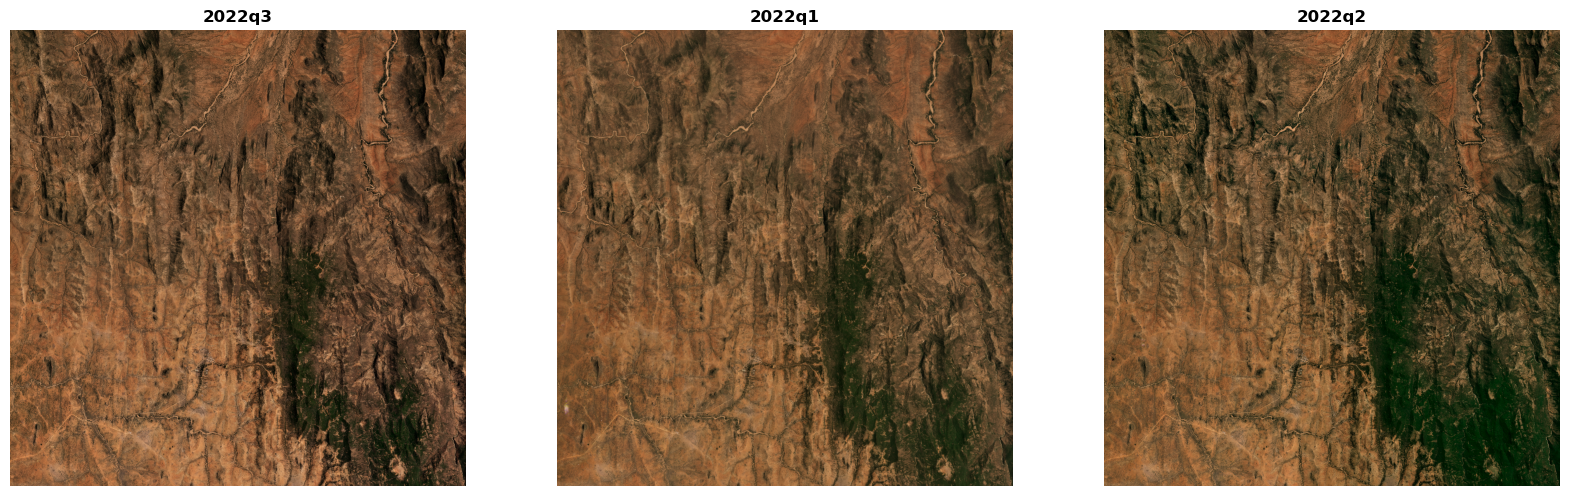

In [ ]:
test_paths = dict_paths[2022]["1235_1026"]

fig, ax = plt.subplots(1, len(test_paths), figsize=(20, 10))

data_test = []

for idx, i in enumerate(test_paths):
    with rasterio.open(i) as src:
        show(src, ax=ax[idx], title=i.parts[-2].split("_")[-2])
        ax[idx].set_axis_off()
        data_test.append(src.read())

### Calculate composites in parallel

In [ ]:
process_composites_parallel(
    dict_paths=dict_paths,
    save_dir="/mnt/drive/composites",
    operation="mean",
    nthreads=10,
)

Processing quads 2020 -> composites:   0%|          | 0/336 [00:00<?, ?it/s]/home/topcat/projects/planet_download/planet_download/composites.py:127: RasterioDeprecationWarning: Source dataset should be opened in read-only mode. Use of datasets opened in modes other than 'r' will be disallowed in a future version.
  cog_translate(
Processing quads 2022 -> composites: 100%|██████████| 776/776 [31:41<00:00,  2.45s/it]


### Now let's explore the composites

{'driver': 'GTiff', 'dtype': 'float64', 'nodata': None, 'width': 4096, 'height': 4096, 'count': 3, 'crs': CRS.from_wkt('PROJCS["WGS 84 / Pseudo-Mercator",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Mercator_1SP"],PARAMETER["central_meridian",0],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=merc +a=6378137 +b=6378137 +lat_ts=0 +lon_0=0 +x_0=0 +y_0=0 +k=1 +units=m +nadgrids=@null +wktext +no_defs"],AUTHORITY["EPSG","3857"]]'), 'transform': Affine(4.77731426716, 0.0, 4128822.519284893,
       0.0, -4.77731426716, 58703.63772112131), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'deflate', 'interleave'

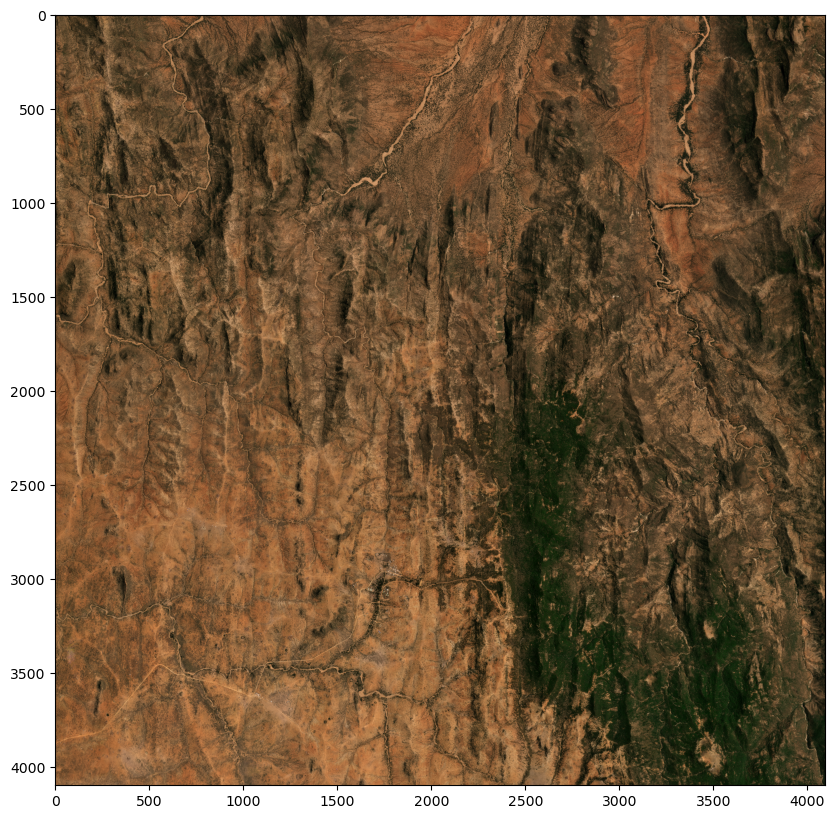

In [ ]:
with rasterio.open("/mnt/drive/composites/2022/1235_1026_composite.tif") as src:
    print(src.profile)

    arr = src.read()
    # Change order of dimensions so that it is (4096, 4096, 3)
    arr = np.moveaxis(arr, 0, -1)

    # Normalize array to range [0, 1]
    arr = (arr - arr.min()) / (arr.max() - arr.min())

    # Plot the array
    fig, ax = plt.subplots(figsize=(10, 10))
    plt.imshow(arr, cmap="gray")
